In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## Step 1: Load the Data

In [2]:
df = pd.read_csv("datasets/DiabetesClassification.csv")

In [3]:
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,feat1,Exercise,Diagnosis
0,45,male,25,Normal,100.0,5.7,no,No,Healthy,0.932037,Regular,No
1,55,Female,30,High,120.0,6.4,yes,Yes,Poor,0.673781,No,Yes
2,65,male,35,High,140.0,7.1,YES,Yes,Poor,0.220245,No,Yes
3,75,Female,40,High,160.0,7.8,Yes,Yes,Poor,NaN,No,Yes
4,40,Male,20,Normal,80.0,5.0,No,No,Healthy,NaN,Regular,No


In [4]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Blood Pressure', 'FBS', 'HbA1c',
       'Family History of Diabetes', 'Smoking', 'Diet', 'feat1', 'Exercise',
       'Diagnosis'],
      dtype='str')

In [5]:
df.columns = [col.lower().strip().replace(' ','_') for col in df.columns]

In [6]:
df.head()

,age,gender,bmi,blood_pressure,fbs,hba1c,family_history_of_diabetes,smoking,diet,feat1,exercise,diagnosis
0,45,male,25,Normal,100.0,5.7,no,No,Healthy,0.932037,Regular,No
1,55,Female,30,High,120.0,6.4,yes,Yes,Poor,0.673781,No,Yes
2,65,male,35,High,140.0,7.1,YES,Yes,Poor,0.220245,No,Yes
3,75,Female,40,High,160.0,7.8,Yes,Yes,Poor,NaN,No,Yes
4,40,Male,20,Normal,80.0,5.0,No,No,Healthy,NaN,Regular,No


In [7]:
(df.isna().sum()/df.shape[0])*100

age                            0.00000
gender                         0.00000
bmi                            0.00000
blood_pressure                 2.34375
fbs                            0.78125
hba1c                          2.34375
family_history_of_diabetes     0.00000
smoking                        0.00000
diet                           0.78125
feat1                         90.62500
exercise                       0.00000
diagnosis                      0.00000
dtype: float64

In [8]:
df = df.drop(columns=['feat1'])

In [9]:
df.head()

,age,gender,bmi,blood_pressure,fbs,hba1c,family_history_of_diabetes,smoking,diet,exercise,diagnosis
0,45,male,25,Normal,100.0,5.7,no,No,Healthy,Regular,No
1,55,Female,30,High,120.0,6.4,yes,Yes,Poor,No,Yes
2,65,male,35,High,140.0,7.1,YES,Yes,Poor,No,Yes
3,75,Female,40,High,160.0,7.8,Yes,Yes,Poor,No,Yes
4,40,Male,20,Normal,80.0,5.0,No,No,Healthy,Regular,No


In [10]:
(df.isna().sum()/df.shape[0])*100

age                           0.00000
gender                        0.00000
bmi                           0.00000
blood_pressure                2.34375
fbs                           0.78125
hba1c                         2.34375
family_history_of_diabetes    0.00000
smoking                       0.00000
diet                          0.78125
exercise                      0.00000
diagnosis                     0.00000
dtype: float64

In [11]:
df['blood_pressure'] = df['blood_pressure'].fillna(df['blood_pressure'].mode()[0])

<Axes: xlabel='hba1c', ylabel='Count'>

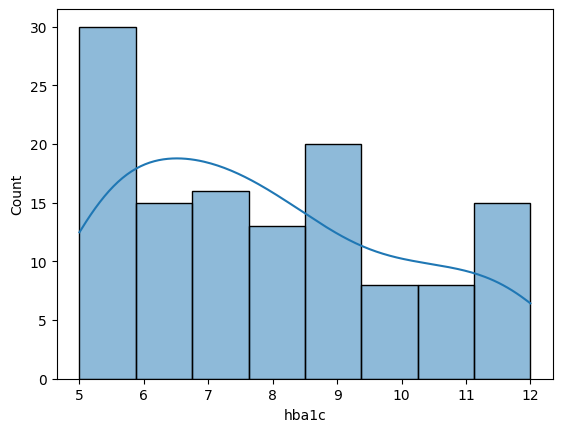

In [12]:
sns.histplot(df['hba1c'],kde=True)

In [13]:
df['fbs'] = df['fbs'].fillna(df['fbs'].median())
df['hba1c'] = df['hba1c'].fillna(df['hba1c'].median())

In [14]:
(df.isna().sum()/df.shape[0])*100

age                           0.00000
gender                        0.00000
bmi                           0.00000
blood_pressure                0.00000
fbs                           0.00000
hba1c                         0.00000
family_history_of_diabetes    0.00000
smoking                       0.00000
diet                          0.78125
exercise                      0.00000
diagnosis                     0.00000
dtype: float64

In [15]:
df['diet'] = df['diet'].fillna(df['diet'].mode()[0])

In [16]:
df.head()

,age,gender,bmi,blood_pressure,fbs,hba1c,family_history_of_diabetes,smoking,diet,exercise,diagnosis
0,45,male,25,Normal,100.0,5.7,no,No,Healthy,Regular,No
1,55,Female,30,High,120.0,6.4,yes,Yes,Poor,No,Yes
2,65,male,35,High,140.0,7.1,YES,Yes,Poor,No,Yes
3,75,Female,40,High,160.0,7.8,Yes,Yes,Poor,No,Yes
4,40,Male,20,Normal,80.0,5.0,No,No,Healthy,Regular,No


In [17]:
str_col_list = ['gender','blood_pressure','family_history_of_diabetes','smoking','diet','exercise']

In [18]:
for col in str_col_list:
    print("Before")
    print("#"*15)
    print(df[col].value_counts())
    df[col] = df[col].str.lower().str.strip()
    print("After")
    print("#"*15)
    print(df[col].value_counts())

Before
###############
gender
Male      66
Female    57
male       2
femle      2
female     1
Name: count, dtype: int64
After
###############
gender
male      68
female    58
femle      2
Name: count, dtype: int64
Before
###############
blood_pressure
High      80
Normal    39
Low        9
Name: count, dtype: int64
After
###############
blood_pressure
high      80
normal    39
low        9
Name: count, dtype: int64
Before
###############
family_history_of_diabetes
No     76
Yes    49
no      1
yes     1
YES     1
Name: count, dtype: int64
After
###############
family_history_of_diabetes
no     77
yes    51
Name: count, dtype: int64
Before
###############
smoking
Yes    79
No     49
Name: count, dtype: int64
After
###############
smoking
yes    79
no     49
Name: count, dtype: int64
Before
###############
diet
Poor       80
Healthy    48
Name: count, dtype: int64
After
###############
diet
poor       80
healthy    48
Name: count, dtype: int64
Before
###############
exercise
No         

In [19]:
df['gender'] = df['gender'].replace({'femle':'female'})

In [20]:
df['gender'].value_counts()

gender
male      68
female    60
Name: count, dtype: int64

In [21]:
df.head()

,age,gender,bmi,blood_pressure,fbs,hba1c,family_history_of_diabetes,smoking,diet,exercise,diagnosis
0,45,male,25,normal,100.0,5.7,no,no,healthy,regular,No
1,55,female,30,high,120.0,6.4,yes,yes,poor,no,Yes
2,65,male,35,high,140.0,7.1,yes,yes,poor,no,Yes
3,75,female,40,high,160.0,7.8,yes,yes,poor,no,Yes
4,40,male,20,normal,80.0,5.0,no,no,healthy,regular,No


In [22]:
df = pd.concat([df,pd.get_dummies(df['blood_pressure'],drop_first=True,prefix='blood_pressure')],axis=1)
df = pd.concat([df,pd.get_dummies(df['gender'],drop_first=True,prefix='gender')],axis=1)
df = pd.concat([df,pd.get_dummies(df['family_history_of_diabetes'],drop_first=True,prefix='family_history_of_diabetes')],axis=1)

In [23]:
df.head()

,age,gender,bmi,blood_pressure,fbs,hba1c,family_history_of_diabetes,smoking,diet,exercise,diagnosis,blood_pressure_low,blood_pressure_normal,gender_male,family_history_of_diabetes_yes
0,45,male,25,normal,100.0,5.7,no,no,healthy,regular,No,False,True,True,False
1,55,female,30,high,120.0,6.4,yes,yes,poor,no,Yes,False,False,False,True
2,65,male,35,high,140.0,7.1,yes,yes,poor,no,Yes,False,False,True,True
3,75,female,40,high,160.0,7.8,yes,yes,poor,no,Yes,False,False,False,True
4,40,male,20,normal,80.0,5.0,no,no,healthy,regular,No,False,True,True,False


In [24]:
df = df.drop(columns=['blood_pressure','gender','family_history_of_diabetes'])

In [25]:
df.head()

,age,bmi,fbs,hba1c,smoking,diet,exercise,diagnosis,blood_pressure_low,blood_pressure_normal,gender_male,family_history_of_diabetes_yes
0,45,25,100.0,5.7,no,healthy,regular,No,False,True,True,False
1,55,30,120.0,6.4,yes,poor,no,Yes,False,False,False,True
2,65,35,140.0,7.1,yes,poor,no,Yes,False,False,True,True
3,75,40,160.0,7.8,yes,poor,no,Yes,False,False,False,True
4,40,20,80.0,5.0,no,healthy,regular,No,False,True,True,False


In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
encoder = LabelEncoder()

In [28]:
df['smoking'] = encoder.fit_transform(df['smoking'])
df['diet'] = encoder.fit_transform(df['diet'])
df['exercise'] = encoder.fit_transform(df['exercise'])

In [29]:
df.head()

,age,bmi,fbs,hba1c,smoking,diet,exercise,diagnosis,blood_pressure_low,blood_pressure_normal,gender_male,family_history_of_diabetes_yes
0,45,25,100.0,5.7,0,0,1,No,False,True,True,False
1,55,30,120.0,6.4,1,1,0,Yes,False,False,False,True
2,65,35,140.0,7.1,1,1,0,Yes,False,False,True,True
3,75,40,160.0,7.8,1,1,0,Yes,False,False,False,True
4,40,20,80.0,5.0,0,0,1,No,False,True,True,False


In [30]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
model = DecisionTreeClassifier()

In [33]:
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [34]:
y_pred = model.predict(X_test)

In [36]:
cm = confusion_matrix(y_test,y_pred)

In [37]:
disp = ConfusionMatrixDisplay(cm)

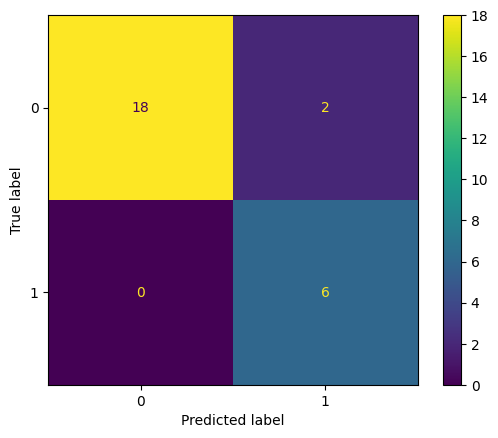

In [40]:
disp.plot()

In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       1.00      0.90      0.95        20
         Yes       0.75      1.00      0.86         6

    accuracy                           0.92        26
   macro avg       0.88      0.95      0.90        26
weighted avg       0.94      0.92      0.93        26



In [43]:
sorted(model.feature_importances_)

[np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.029290043290043345),
 np.float64(0.04709956709956709),
 np.float64(0.07064935064935064),
 np.float64(0.20946795140343527),
 np.float64(0.6434930875576036)]

In [44]:
model.feature_importances_

array([0.02929004, 0.        , 0.04709957, 0.07064935, 0.        ,
       0.        , 0.20946795, 0.        , 0.        , 0.        ,
       0.64349309])

In [45]:
df.columns

Index(['age', 'bmi', 'fbs', 'hba1c', 'smoking', 'diet', 'exercise',
       'diagnosis', 'blood_pressure_low', 'blood_pressure_normal',
       'gender_male', 'family_history_of_diabetes_yes'],
      dtype='str')